In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
df = pd.read_csv("outputs/sales_data.csv")
df.head()


,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date,Revenue
0,1001,27,Accessories,West,5,60000,2024-01-01,300000
1,1002,17,Laptop,East,4,60000,2024-01-02,240000
2,1003,9,Tablet,North,5,15000,2024-01-03,75000
3,1004,33,Laptop,South,4,15000,2024-01-04,60000
4,1005,20,Accessories,South,5,8000,2024-01-05,40000


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order_ID     150 non-null    int64 
 1   Customer_ID  150 non-null    int64 
 2   Product      150 non-null    object
 3   Region       150 non-null    object
 4   Quantity     150 non-null    int64 
 5   Unit_Price   150 non-null    int64 
 6   Order_Date   150 non-null    object
 7   Revenue      150 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 9.5+ KB


Order_ID       0
Customer_ID    0
Product        0
Region         0
Quantity       0
Unit_Price     0
Order_Date     0
Revenue        0
dtype: int64

In [4]:
if "Revenue" not in df.columns:
    df["Revenue"] = df["Quantity"] * df["Unit_Price"]

df[["Quantity","Unit_Price","Revenue"]].head()


,Quantity,Unit_Price,Revenue
0,5,60000,300000
1,4,60000,240000
2,5,15000,75000
3,4,15000,60000
4,5,8000,40000


In [5]:
df["Cost"] = df["Quantity"] * df["Unit_Price"] * 0.7
df["Profit"] = df["Revenue"] - df["Cost"]
df[["Revenue","Cost","Profit"]].head()


,Revenue,Cost,Profit
0,300000,210000.0,90000.0
1,240000,168000.0,72000.0
2,75000,52500.0,22500.0
3,60000,42000.0,18000.0
4,40000,28000.0,12000.0


In [6]:
total_revenue = df["Revenue"].sum()
total_profit  = df["Profit"].sum()
profit_margin = (total_profit / total_revenue) * 100
avg_order_value = df["Revenue"].mean()
revenue_per_customer = df.groupby("Customer_ID")["Revenue"].sum().mean()

kpi_summary = pd.DataFrame({
    "KPI": ["Total Revenue","Total Profit","Profit Margin (%)","Avg Order Value","Revenue per Customer"],
    "Value": [total_revenue, total_profit, profit_margin, avg_order_value, revenue_per_customer]
})

kpi_summary


,KPI,Value
0,Total Revenue,1.310200e+07
1,Total Profit,3.930600e+06
2,Profit Margin (%),3.000000e+01
3,Avg Order Value,8.734667e+04
4,Revenue per Customer,3.359487e+05


In [7]:
os.makedirs("outputs", exist_ok=True)
kpi_summary.to_csv("outputs/kpi_summary.csv", index=False)


In [8]:
product_profit = (df.groupby("Product")
                    .agg(Revenue=("Revenue","sum"),
                         Profit=("Profit","sum"))
                    .sort_values("Profit", ascending=False)
                    .reset_index())

product_profit.head()


,Product,Revenue,Profit
0,Mobile,3646000,1093800.0
1,Tablet,3489000,1046700.0
2,Laptop,3356000,1006800.0
3,Accessories,2611000,783300.0


In [9]:
product_profit.to_csv("outputs/product_profit.csv", index=False)


In [10]:
customer_profit = (df.groupby("Customer_ID")
                     .agg(Revenue=("Revenue","sum"),
                          Profit=("Profit","sum"),
                          Orders=("Order_ID","count"))
                     .sort_values("Profit", ascending=False)
                     .reset_index())

customer_profit.head()


,Customer_ID,Revenue,Profit,Orders
0,1,980000,294000.0,7
1,34,940000,282000.0,8
2,27,840000,252000.0,5
3,21,736000,220800.0,6
4,10,580000,174000.0,5


In [11]:
product_profit.to_csv("outputs/product_profit.csv", index=False)


In [12]:
customer_profit = (df.groupby("Customer_ID")
                     .agg(Revenue=("Revenue","sum"),
                          Profit=("Profit","sum"),
                          Orders=("Order_ID","count"))
                     .sort_values("Profit", ascending=False)
                     .reset_index())

customer_profit.head()


,Customer_ID,Revenue,Profit,Orders
0,1,980000,294000.0,7
1,34,940000,282000.0,8
2,27,840000,252000.0,5
3,21,736000,220800.0,6
4,10,580000,174000.0,5


In [13]:
customer_profit.to_csv("outputs/customer_profit.csv", index=False)


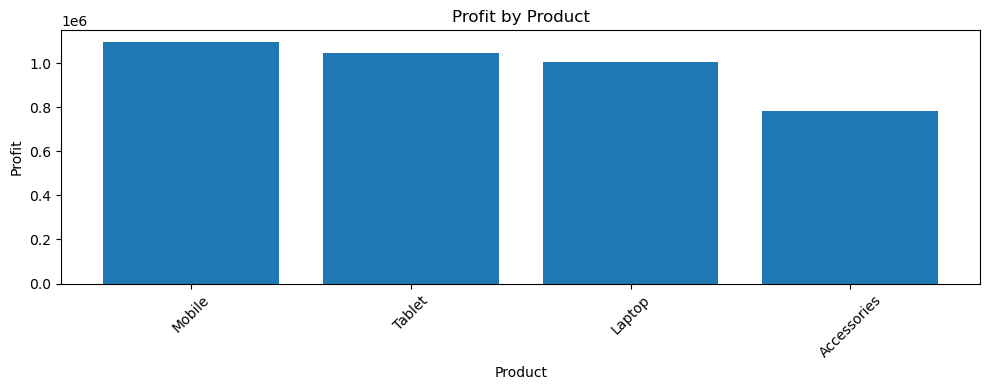

In [14]:
plt.figure(figsize=(10,4))
plt.bar(product_profit["Product"], product_profit["Profit"])
plt.xticks(rotation=45)
plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


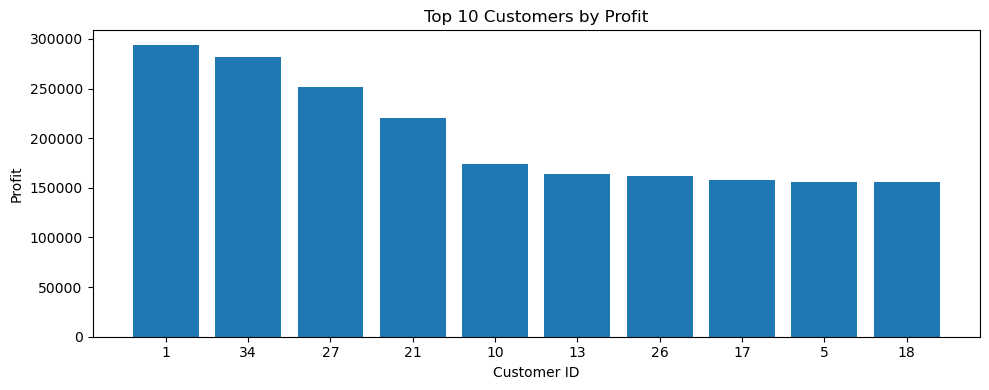

In [15]:
top10 = customer_profit.head(10)

plt.figure(figsize=(10,4))
plt.bar(top10["Customer_ID"].astype(str), top10["Profit"])
plt.title("Top 10 Customers by Profit")
plt.xlabel("Customer ID")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


In [16]:
os.makedirs("outputs/plots", exist_ok=True)

plt.figure(figsize=(10,4))
plt.bar(product_profit["Product"], product_profit["Profit"])
plt.xticks(rotation=45)
plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("outputs/plots/profit_by_product.png", dpi=200)
plt.close()

plt.figure(figsize=(10,4))
plt.bar(top10["Customer_ID"].astype(str), top10["Profit"])
plt.title("Top 10 Customers by Profit")
plt.xlabel("Customer ID")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("outputs/plots/top_customers_profit.png", dpi=200)
plt.close()

print("Plots saved.")


Plots saved.


In [17]:
print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin (%):", round(profit_margin, 2))


Total Revenue: 13102000
Total Profit: 3930600.0
Profit Margin (%): 30.0
